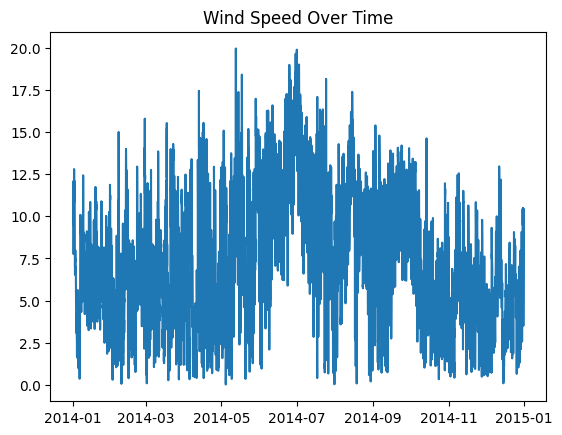

Rolling signature shape: (6107, 19, 12)
Epoch 1/250
96/96 [==============================] - 2s 12ms/step - loss: 0.0728 - val_loss: 0.0215
Epoch 2/250
96/96 [==============================] - 1s 9ms/step - loss: 0.0235 - val_loss: 0.0183
Epoch 3/250
96/96 [==============================] - 1s 10ms/step - loss: 0.0204 - val_loss: 0.0151
Epoch 4/250
96/96 [==============================] - 1s 10ms/step - loss: 0.0186 - val_loss: 0.0156
Epoch 5/250
96/96 [==============================] - 1s 9ms/step - loss: 0.0181 - val_loss: 0.0137
Epoch 6/250
96/96 [==============================] - 1s 9ms/step - loss: 0.0176 - val_loss: 0.0140
Epoch 7/250
96/96 [==============================] - 1s 9ms/step - loss: 0.0171 - val_loss: 0.0144
Epoch 8/250
96/96 [==============================] - 1s 11ms/step - loss: 0.0167 - val_loss: 0.0120
Epoch 9/250
96/96 [==============================] - 1s 9ms/step - loss: 0.0163 - val_loss: 0.0132
Epoch 10/250
96/96 [==============================] - 1s 9ms/step

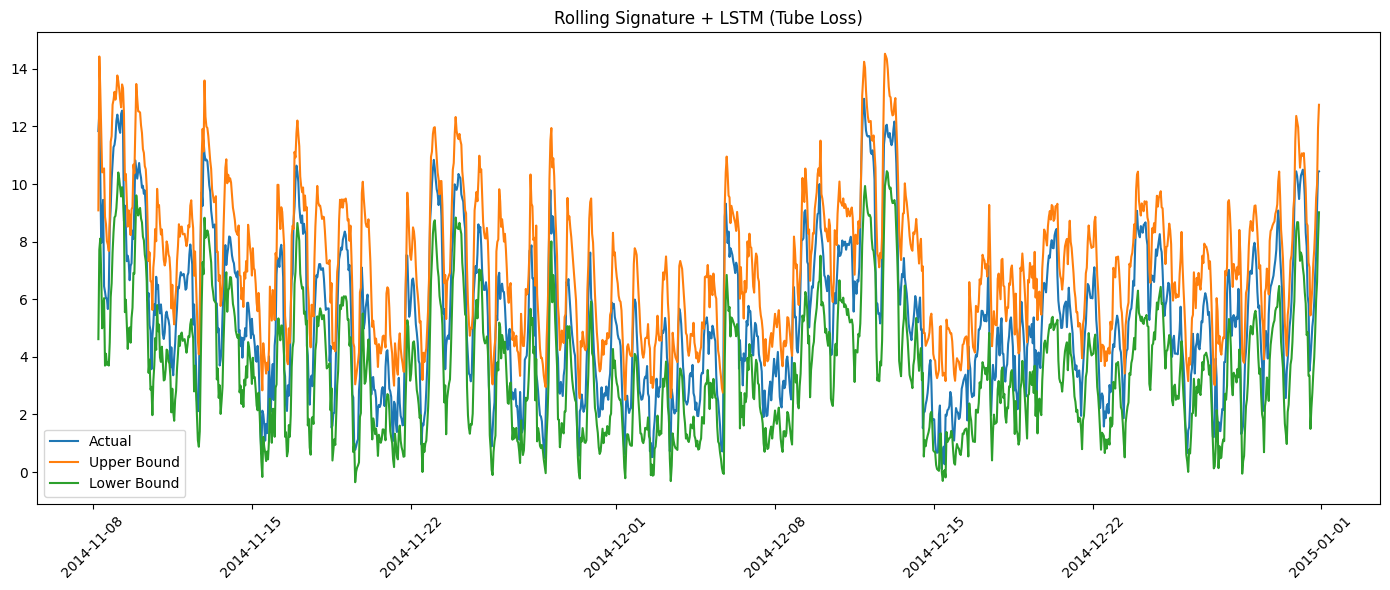

In [2]:
# ==========================================================
# FULL PIPELINE: LeadLag → Rolling Signatures → LSTM (Tube Loss)
# ==========================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import signatory
from torch import nn
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, TransformerMixin

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

from keras.layers import LSTM, GRU, Dense, Dropout, concatenate


# ==========================================================
# 0. REPRODUCIBILITY
# ==========================================================
SEED = 48
np.random.seed(SEED)
torch.manual_seed(SEED)
tf.keras.utils.set_random_seed(SEED)
tf.config.experimental.enable_op_determinism()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# ==========================================================
# 1. LOAD DATA
# ==========================================================
df = pd.read_csv(
    "/mnt/alpha/Research/Signature_based_UQ/dataset/Jaisalmer.csv",
    index_col="Date/Time",
    parse_dates=True
)

df = df[df.index.minute == 0]
df = pd.DataFrame({"wind": df["120m"]}, index=df.index)

plt.plot(df)
plt.title("Wind Speed Over Time")
plt.show()


# ==========================================================
# 2. CONFIDENCE / TUBE LOSS
# ==========================================================
r = 0.5
q = 0.95
delta = 0.005



def confidence_loss(y_true, y_pred):
    y_true = y_true[:, 0]
    f1 = y_pred[:, 0]
    f2 = y_pred[:, 1]

    c1 = (1 - q) * (y_true - f2)
    c2 = (1 - q) * (f1 - y_true)
    c3 = q * (f2 - y_true)
    c4 = q * (y_true - f1)

    cond1 = tf.logical_and(y_true <= f1, y_true >= f2)
    cond2 = y_true > (r * f1 + (1 - r) * f2)
    cond3 = f2 > y_true

    loss = tf.where(cond1,
                    tf.where(cond2, c1, c2),
                    tf.where(cond3, c3, c4))

    return loss + delta * tf.abs(f1 - f2)


# ==========================================================
# 3. WINDOWING
# ==========================================================
input_window = 24
val_frac = 0.15
test_frac = 0.15

split_val = int(len(df) * (1 - val_frac - test_frac))
split_test = int(len(df) * (1 - test_frac))

train = df[:split_val]
val   = df[split_val:split_test]
test  = df[split_test:]


def make_windows(data, win):
    X, Y = [], []
    arr = data.values
    for i in range(len(arr) - win - 1):
        X.append(arr[i:i+win])
        Y.append(arr[i+win])
    return np.array(X), np.array(Y)


train_x, train_y = make_windows(train, input_window)
val_x,   val_y   = make_windows(val,   input_window)
test_x,  test_y  = make_windows(test,  input_window)

train_y = train_y.reshape(-1, 1)
val_y   = val_y.reshape(-1, 1)
test_y  = test_y.reshape(-1, 1)


# ==========================================================
# 4. NORMALIZATION
# ==========================================================
scaler_x = MinMaxScaler().fit(train_x.reshape(-1, 1))
scaler_y = MinMaxScaler().fit(train_y)

train_x = scaler_x.transform(train_x.reshape(-1, 1)).reshape(train_x.shape)
val_x   = scaler_x.transform(val_x.reshape(-1, 1)).reshape(val_x.shape)
test_x  = scaler_x.transform(test_x.reshape(-1, 1)).reshape(test_x.shape)

train_y_s = scaler_y.transform(train_y)
val_y_s   = scaler_y.transform(val_y)
test_y_s  = scaler_y.transform(test_y)


# ==========================================================
# 5. LEAD–LAG TRANSFORM
# ==========================================================
class LeadLag(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = torch.tensor(X, dtype=torch.float32)
        X = X.squeeze(-1).unsqueeze(-1)
        Xr = X.repeat_interleave(2, dim=1)
        lead = Xr[:, 1:, :]
        lag  = Xr[:, :-1, :]
        return torch.cat([lead, lag], dim=2)

leadlag = LeadLag()


# ==========================================================
# 6. SIGNATURE EXTRACTOR
# ==========================================================
class SignatureExtractor(nn.Module):
    def __init__(self, depth):
        super().__init__()
        self.signature = signatory.Signature(depth=depth)

    def forward(self, x):
        B, T, _ = x.shape
        t = torch.linspace(0, 1, T, device=x.device)
        t = t.view(1, T, 1).repeat(B, 1, 1)
        x_aug = torch.cat([x, t], dim=2)
        return self.signature(x_aug, basepoint=True)


sig_depth = 2
sig_extractor = SignatureExtractor(sig_depth).to(device).eval()


# ==========================================================
# 7. ROLLING SIGNATURE FEATURES
# ==========================================================
subwindow = 6
stride = 1



def extract_rolling_signatures(X):
    all_feats = []
    with torch.no_grad():
        for i in range(len(X)):
            feats = []
            for t in range(0, X.shape[1] - subwindow + 1, stride):
                sub = X[i:i+1, t:t+subwindow]
                path = leadlag.transform(sub).to(device)
                sig = sig_extractor(path)
                feats.append(sig.cpu().numpy()[0])
            all_feats.append(np.stack(feats, axis=0))
    return np.array(all_feats)





trainF = extract_rolling_signatures(train_x)
valF   = extract_rolling_signatures(val_x)
testF  = extract_rolling_signatures(test_x)

print("Rolling signature shape:", trainF.shape)  # (N, K, D)


# ==========================================================
# 8. LSTM MODEL
# ==========================================================
# def create_lstm(input_shape):
#     model = Sequential()
#     model.add(LSTM(32, return_sequences=True, input_shape=input_shape))
#     model.add(LSTM(16))
#     model.add(Dense(2))
#     return model

def create_lstm(input_shape, layer_units=[32,32], output_units=2, dropout_rate=0.1):
    model = Sequential()
    for i, units in enumerate(layer_units[:-1]):
        model.add(LSTM(units=units, return_sequences=True, input_shape=input_shape, activation="relu"))
        if dropout_rate > 0.0:
            model.add(Dropout(dropout_rate))  # Adding dropout between LSTM layers
    # Last LSTM layer without return_sequences
    model.add(LSTM(units=layer_units[-1], activation="relu"))
    if dropout_rate > 0.0:
        model.add(Dropout(dropout_rate))  # Adding dropout after the last LSTM layer
    model.add(Dense(output_units))  # Output layer
    return model


model = create_lstm((trainF.shape[1], trainF.shape[2]))
model.compile(loss=confidence_loss, optimizer=Adam(0.001))


# ==========================================================
# 9. TRAIN
# ==========================================================
model.fit(
    trainF, train_y_s,
    validation_data=(valF, val_y_s),
    epochs=250,
    batch_size=64,
    callbacks=[tf.keras.callbacks.EarlyStopping(patience=15, restore_best_weights=True)],
    verbose=1
)


# ==========================================================
# 10. PREDICT + METRICS
# ==========================================================

pred = model.predict(testF)

u = scaler_y.inverse_transform(pred[:, 0].reshape(-1, 1)).ravel()
l = scaler_y.inverse_transform(pred[:, 1].reshape(-1, 1)).ravel()
y = scaler_y.inverse_transform(test_y_s).ravel()

PICP = np.mean((u > y) & (l < y))
MPIW = np.mean(u - l)

# print("PICP =", PICP)
# print("MPIW =", MPIW)

# ==========================================================
# 12B. CWC EVALUATION (LUBE METRIC)
# ==========================================================

PICP_TARGET = 0.95

def compute_cwc(y_true, y_l, y_u,
                mu=0.95,
                gamma=1.0,
                eta=50.0,
                normalize=True):
    """
    Coverage Width-Based Criterion (CWC)

    Parameters
    ----------
    y_true : array
        True targets
    y_l : array
        Lower prediction bounds
    y_u : array
        Upper prediction bounds
    mu : float
        Nominal coverage level (e.g. 0.95)
    gamma : float
        Penalty activation coefficient
    eta : float
        Penalty sharpness
    normalize : bool
        Whether to normalize MPIW

    Returns
    -------
    cwc : float
    picp : float
    mpiw : float
    nmpiw : float
    """

    # Coverage
    picp = np.mean((y_true >= y_l) & (y_true <= y_u))

    # Width
    mpiw = np.mean(y_u - y_l)

    if normalize:
        y_range = np.max(y_true) - np.min(y_true)
        nmpiw = mpiw / y_range
    else:
        nmpiw = mpiw

    # CWC penalty
    if picp >= mu:
        cwc = nmpiw
    else:
        cwc = nmpiw * (1 + gamma * np.exp(-eta * (picp - mu)))

    return cwc, picp, mpiw, nmpiw

# -------------------------------
# Compute CWC on TEST set
# -------------------------------
CWC_test, PICP_test, MPIW_test, NMPIW_test = compute_cwc(
    y_true=y,
    y_l=l,
    y_u=u,
    mu=PICP_TARGET,
    gamma=1.0,
    eta=50.0,
    normalize=True
)


print("\n===== CWC EVALUATION (TEST) =====")
print(f"PICP   = {PICP_test:.6f}")
print(f"MPIW   = {MPIW_test:.6f}")
print(f"NMPIW  = {NMPIW_test:.6f}")
print(f"CWC    = {CWC_test:.6f}")

#----------------------------------------
# APPEND TO CSV
#-------------------------------------

import os
import csv
from datetime import datetime

def append_results_to_csv(
    csv_path,
    dataset,
    delta,
    sig_depth,
    lstm_layers,
    dropout,
    train_metrics,
    val_metrics,
    test_metrics
):
    """
    Appends experiment results to a CSV file.
    """

    # Ensure directory exists
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    header = [
        "timestamp",
        "dataset",
        "delta",
        "sig_depth",
        "lstm_layers",
        "dropout",
        "split",
        "CWC",
        "PICP",
        "MPIW",
        "NMPIW",
    ]

    rows = []
    timestamp = datetime.now().isoformat(timespec="seconds")

    for split_name, metrics in zip(
        ["train", "val", "test"],
        [train_metrics, val_metrics, test_metrics]
    ):
        CWC, PICP, MPIW, NMPIW = metrics
        rows.append([
            timestamp,
            dataset,
            delta,
            sig_depth,
            str(lstm_layers),
            dropout,
            split_name,
            CWC,
            PICP,
            MPIW,
            NMPIW
        ])

    file_exists = os.path.isfile(csv_path)

    with open(csv_path, mode="a", newline="") as f:
        writer = csv.writer(f)
        if not file_exists:
            writer.writerow(header)
        writer.writerows(rows)






# ==========================================================
# 11. INDEX MATCHING
# ==========================================================
idx = test.index[np.arange(input_window, input_window + len(y))]


# ==========================================================
# 12. PLOT
# ==========================================================
plt.figure(figsize=(14, 6))
plt.plot(idx, y, label="Actual")
plt.plot(idx, u, label="Upper Bound")
plt.plot(idx, l, label="Lower Bound")
plt.legend()
plt.title("Rolling Signature + LSTM (Tube Loss)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
